In [1]:
!unzip bitter_dataset.zip -d /content/datasets/bitter

Archive:  bitter_dataset.zip
   creating: /content/datasets/bitter/bitter_dataset/1 days/
  inflating: /content/datasets/bitter/bitter_dataset/1 days/1.jpg  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/2.jpg  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/3.jpg  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/5.PNG  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/7.jpg  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/8.PNG  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/89.PNG  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/899.PNG  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/9.jpg  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/bitterone (1).jpg  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/bitterone (10).jpg  
  inflating: /content/datasets/bitter/bitter_dataset/1 days/bitterone (100).jpg  
  inflating: /content/datasets/bitter/bitter_dataset

In [2]:

import os
import shutil

base_dir = '/content/datasets'
combined_dir = '/content/combined_dataset'
os.makedirs(combined_dir, exist_ok=True)

foods = [ 'bitter']

food_stages = {

    'bitter': ['1 days', '2 days', '3 days', '4 days'],

}

for food in foods:
    food_path = os.path.join(base_dir, food)
    if os.path.exists(food_path):
        nested_folder = None
        for item in os.listdir(food_path):
            full_path = os.path.join(food_path, item)
            if os.path.isdir(full_path) and item.lower() == f"{food}_dataset".lower():
                nested_folder = full_path
                break
        if nested_folder:
            actual_stages = [d for d in os.listdir(nested_folder) if os.path.isdir(os.path.join(nested_folder, d))]
        else:
            actual_stages = [d for d in os.listdir(food_path) if os.path.isdir(os.path.join(food_path, d))]
        print(f"Checking {food}: Nested folder? {nested_folder}, Expected stages: {food_stages[food]}, Actual stages: {actual_stages}")
        for stage in food_stages[food]:
            src = os.path.join(nested_folder if nested_folder else food_path, stage)
            if os.path.exists(src):
                dst_class = f"{food}_{stage}"
                dst = os.path.join(combined_dir, dst_class)
                os.makedirs(dst, exist_ok=True)
                for img in os.listdir(src):
                    if os.path.isfile(os.path.join(src, img)):
                        shutil.copy(os.path.join(src, img), os.path.join(dst, img))
            else:
                print(f"Warning: {src} not found for {food}")

print("Combined dataset classes:", os.listdir(combined_dir))

Checking bitter: Nested folder? /content/datasets/bitter/bitter_dataset, Expected stages: ['1 days', '2 days', '3 days', '4 days'], Actual stages: ['1 days', '4 days', '3 days', '2 days']
Combined dataset classes: ['bitter_2 days', 'bitter_4 days', 'bitter_1 days', 'bitter_3 days']


Found subdirectories: ['bitter_2 days', 'bitter_4 days', 'bitter_1 days', 'bitter_3 days']
Subdirectory bitter_2 days: 200 images
Subdirectory bitter_4 days: 200 images
Subdirectory bitter_1 days: 200 images
Subdirectory bitter_3 days: 200 images
Found 640 images belonging to 4 classes.
Found 160 images belonging to 4 classes.
Class indices: {'bitter_1 days': 0, 'bitter_2 days': 1, 'bitter_3 days': 2, 'bitter_4 days': 3}
Number of classes: 4
Class distribution: {'bitter_1 days': np.int64(160), 'bitter_2 days': np.int64(160), 'bitter_3 days': np.int64(160), 'bitter_4 days': np.int64(160)}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6282 - loss: 1.2458 - val_accuracy: 0.8625 - val_loss: 0.4461 - learning_rate: 0.0010
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8692 - loss: 0.5310 - val_accuracy: 0.8313 - val_loss: 0.5613 - learning_rate: 0.0010
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8636 - loss: 0.4885 - val_accuracy: 0.9000 - val_loss: 0.4420 - learning_rate: 0.0010
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9008 - loss: 0.4018 - val_accuracy: 0.8062 - val_loss: 0.6099 - learning_rate: 0.0010
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8768 - loss: 0.4323 - val_accuracy: 0.8938 - val_loss: 0.4542 - learning_rate: 0.0010
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8955 - loss: 0.3970 - val_accuracy: 0.7750 - val_loss: 0.7455 - learning_rate: 0.0010
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8725 - loss: 0.5081 - val_accuracy: 

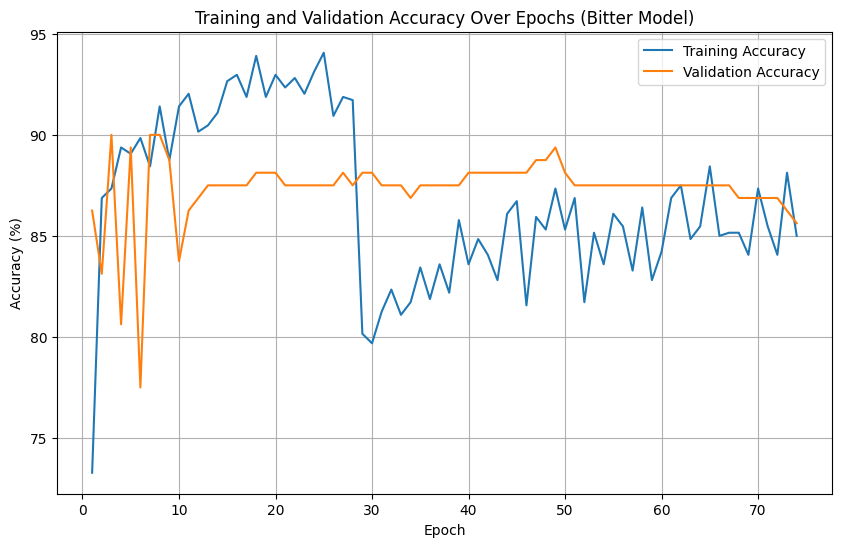

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
import random
import os

# Custom Cutout augmentation
def cutout(image):
    if random.random() < 0.5:  # Apply Cutout with 50% probability
        h, w = image.shape[:2]
        cutout_size = random.randint(20, 50)  # Random cutout size
        x = random.randint(0, w - cutout_size)
        y = random.randint(0, h - cutout_size)
        image[y:y+cutout_size, x:x+cutout_size, :] = 0
    return image

# Combined preprocessing function for MobileNetV2 and Cutout
def preprocess_with_cutout(x):
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = cutout(x)
    return x

# Step 1: Set up data generators with enhanced augmentation for bitter dataset
datagen_aug = ImageDataGenerator(
    preprocessing_function=preprocess_with_cutout,  # Combine MobileNetV2 preprocessing and Cutout
    validation_split=0.2,
    rotation_range=60,
    width_shift_range=0.5,
    height_shift_range=0.5,
    shear_range=0.5,
    zoom_range=[0.4, 1.6],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    brightness_range=[0.4, 1.6],
    channel_shift_range=30.0
)

datagen_no_aug = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

# Ensure dataset directory exists
data_dir = '/content/combined_dataset'
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Dataset directory {data_dir} not found. Please update the path or ensure the dataset exists.")

# Check dataset structure
subdirs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
print(f"Found subdirectories: {subdirs}")
if len(subdirs) != 4:
    print(f"Warning: Expected 4 subdirectories, found {len(subdirs)}. Please check dataset structure.")

# Count images in each subdirectory
for subdir in subdirs:
    subdir_path = os.path.join(data_dir, subdir)
    image_files = [f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Subdirectory {subdir}: {len(image_files)} images")

train_generator = datagen_aug.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen_no_aug.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Verify class indices and check for balance
print("Class indices:", train_generator.class_indices)
print("Number of classes:", len(train_generator.class_indices))
class_counts = np.bincount(train_generator.classes)
print("Class distribution:", dict(zip(train_generator.class_indices.keys(), class_counts)))

# Compute class weights for potential imbalance
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))

# Step 2: Build MobileNetV2 model optimized for 4-class bitter classification
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.00005))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.00005))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
predictions = Dense(4, activation='softmax')(x)

new_model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers initially
for layer in base_model.layers:
    layer.trainable = False

new_model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, mode='max')
lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.05, patience=8, min_lr=1e-8, mode='max')
checkpoint = ModelCheckpoint('best_mobilenet_bitter_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

# Train initial phase
history = new_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=[early_stop, lr_reduce, checkpoint],
    class_weight=class_weights_dict
)

# Fine-tune more layers (MobileNetV2 has ~154 layers)
for layer in base_model.layers[-100:]:
    layer.trainable = True

new_model.compile(optimizer=AdamW(learning_rate=0.000005, weight_decay=0.00001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Fine-tune
history_fine = new_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=[early_stop, lr_reduce, checkpoint],
    class_weight=class_weights_dict
)

# Evaluate
val_loss_new, val_acc_new = new_model.evaluate(val_generator)
print(f"Bitter Model Validation Accuracy: {val_acc_new * 100:.2f}%")

# Enhanced Test-Time Augmentation (TTA)
def tta_evaluate(model, num_augs=40):
    tta_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input_mobilenetv2,
        rotation_range=50,
        width_shift_range=0.4,
        height_shift_range=0.4,
        shear_range=0.4,
        zoom_range=0.4,
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split=0.2
    )
    preds = []
    y_true = val_generator.classes
    for i in range(num_augs):
        tta_gen = tta_datagen.flow_from_directory(
            data_dir,
            target_size=(224, 224),
            batch_size=32,
            class_mode='categorical',
            subset='validation',
            shuffle=False,
            seed=42 + i
        )
        batch_preds = model.predict(tta_gen, steps=len(tta_gen), verbose=0)
        preds.append(batch_preds)
    avg_preds = np.mean(preds, axis=0)
    acc = np.mean(np.argmax(avg_preds, axis=1) == y_true)
    return acc * 100

tta_acc_new = tta_evaluate(new_model)
print(f"Bitter Model TTA Validation Accuracy: {tta_acc_new:.2f}%")

# Save the final model
new_model.save('improved_mobilenet_bitter_model.keras')

# Plot training and validation accuracy
train_accuracy = history.history['accuracy'] + history_fine.history['accuracy']
val_accuracy = history.history['val_accuracy'] + history_fine.history['val_accuracy']
epochs = list(range(1, len(train_accuracy) + 1))

plt.figure(figsize=(10, 6))
plt.plot(epochs, [acc * 100 for acc in train_accuracy], label='Training Accuracy', color='#1f77b4')
plt.plot(epochs, [acc * 100 for acc in val_accuracy], label='Validation Accuracy', color='#ff7f0e')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Over Epochs (Bitter Model)')
plt.legend()
plt.grid(True)
plt.show()